# CekKlaim.id - Analisis Data & Evaluasi Model

Notebook ini berisi proses lengkap analisis data, pembersihan teks, rekayasa fitur (feature engineering), pemodelan machine learning baseline, serta evaluasi model IndoBERT untuk mendeteksi kebenaran klaim kesehatan dalam Bahasa Indonesia.

### Sesuai Ketentuan, Notebook Ini Memuat:
1. **Data Preprocessing**: Pembersihan teks dan normalisasi bahasa slang menggunakan kamus kolokial.
2. **Exploratory Data Analysis (EDA)**: Analisis statistik dan visualisasi distribusi panjang teks serta sebaran kelas.
3. **Feature Engineering**: Representasi teks menggunakan TF-IDF.
4. **Pemodelan Machine Learning**: Pelatihan model klasifikasi baseline (Logistic Regression).
5. **Evaluasi Model**: Pengujian model baseline dan model deep learning IndoBERT lokal, disertai analisis *shortcut learning*.
6. **Kesimpulan**: Ringkasan temuan dan rekomendasi perbaikan model.

## 1. Import Pustaka & Konfigurasi

Pustaka `torch` dan `transformers` akan di-import terpisah di bagian evaluasi IndoBERT agar cell-cell awal tetap bisa berjalan tanpa GPU/PyTorch.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Semua pustaka berhasil dimuat!")

Semua pustaka berhasil dimuat!


## 2. Memuat Dataset & Kamus Kolokial

In [2]:
# Load data split resmi
train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

# Memuat kamus slang bahasa Indonesia untuk normalisasi
lexicon_df = pd.read_csv("../data/colloquial-indonesian-lexicon.csv")

print(f"Ukuran Dataset Train: {train_df.shape}")
print(f"Ukuran Dataset Val:   {val_df.shape}")
print(f"Ukuran Dataset Test:  {test_df.shape}")
print(f"Ukuran Kamus Slang:   {lexicon_df.shape}")

Ukuran Dataset Train: (2120, 7)
Ukuran Dataset Val:   (454, 7)
Ukuran Dataset Test:  (455, 7)
Ukuran Kamus Slang:   (15006, 7)


## 3. Data Preprocessing

Pada tahap ini, kita akan melakukan:
1. **Pembersihan teks**: Mengubah huruf menjadi kecil (*lowercase*), menghapus angka, tanda baca, serta spasi berlebih.
2. **Normalisasi slang**: Mengubah kata slang/tidak formal menjadi kata formal berdasarkan kamus kolokial.
3. **Penanganan bias (Optional)**: Menghapus kata pemicu bias seperti kata `'salah'` atau `'hoaks'` di awal teks yang berasal dari format TurnBackHoax.id.

In [3]:
# Membuat dictionary pemetaan kata slang ke formal
slang_dict = dict(zip(lexicon_df['slang'], lexicon_df['formal']))

def preprocess_text(text, remove_bias=True):
    if not isinstance(text, str):
        return ""
    
    # Lowercase & strip whitespace
    text = text.lower().strip()
    
    # Menghapus awalan bias yang menunjukkan label secara eksplisit (data leakage)
    if remove_bias:
        # Hapus kata 'salah', 'hoaks', 'keliru', atau 'klarifikasi' di awal kalimat
        text = re.sub(r'^(salah|hoaks|keliru|klarifikasi)\b\s*', '', text)
        text = re.sub(r'^\[(salah|hoaks|keliru|klarifikasi)\]\s*', '', text)
        text = text.replace("turnbackhoax.id", "")
    
    # Menghapus angka dan tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    
    # Normalisasi slang berdasarkan kamus
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    
    return " ".join(normalized_words)

# Uji coba fungsi preprocessing
sample_text = "[SALAH] Minum air es bkin darah beku turnbackhoax.id"
print("Teks Asli:       ", sample_text)
print("Hasil Preprocess:", preprocess_text(sample_text))

# Terapkan pada dataset
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text'] = val_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

Teks Asli:        [SALAH] Minum air es bkin darah beku turnbackhoax.id
Hasil Preprocess: minum air es bikin darah beku


## 4. Exploratory Data Analysis (EDA)

Kita akan menganalisis statistik dari dataset, terutama sebaran label kelas dan panjang karakter/kata dari klaim.

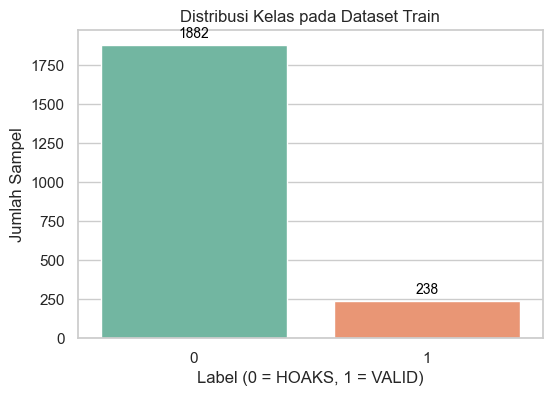

Statistik Deskriptif Panjang Karakter berdasarkan Label:
        count        mean         std   min     25%    50%      75%     max
label                                                                      
0      1882.0   88.176939  210.626311  15.0   50.00   63.0    80.00  2849.0
1       238.0  569.470588  598.714943  55.0  124.25  214.5  1408.75  1561.0


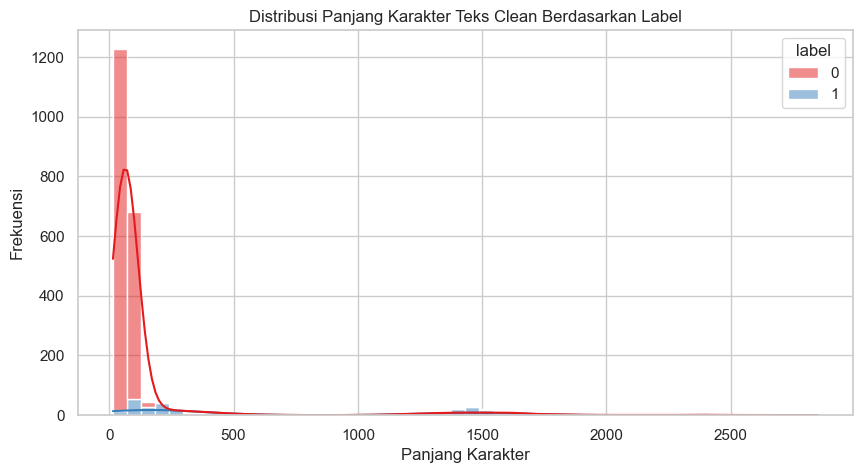

In [4]:
# Hitung panjang karakter dan kata
train_df['char_length'] = train_df['clean_text'].apply(len)
train_df['word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))

# 1. Distribusi Kelas (Label 0 = HOAKS, 1 = VALID)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Distribusi Kelas pada Dataset Train')
plt.xlabel('Label (0 = HOAKS, 1 = VALID)')
plt.ylabel('Jumlah Sampel')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# 2. Statistik Panjang Karakter berdasarkan Label
print("Statistik Deskriptif Panjang Karakter berdasarkan Label:")
print(train_df.groupby('label')['char_length'].describe())

# 3. Visualisasi Distribusi Panjang Karakter
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='char_length', hue='label', kde=True, bins=50, palette='Set1', multiple='stack')
plt.title('Distribusi Panjang Karakter Teks Clean Berdasarkan Label')
plt.xlabel('Panjang Karakter')
plt.ylabel('Frekuensi')
plt.show()

> **Temuan EDA Penting:**
>
* Terdapat ketidakseimbangan kelas (*class imbalance*) yang sangat ekstrim, di mana kelas HOAKS jauh lebih banyak daripada kelas VALID.
* Kelas VALID (1) memiliki panjang karakter rata-rata dan median yang jauh lebih tinggi daripada kelas HOAKS (0). Ini mengindikasikan bahwa data VALID berupa artikel medis yang panjang, sedangkan HOAKS berupa judul klaim singkat. Ini merupakan salah satu celah bias struktural (*shortcut learning*) bagi model.

## 5. Feature Engineering

Kita akan menggunakan representasi **TF-IDF (Term Frequency-Inverse Document Frequency)** dengan pembatasan fitur untuk mengubah teks bersih menjadi vektor numerik.

In [5]:
# Inisialisasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Ekstraksi fitur dari dataset
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val = vectorizer.transform(val_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

print(f"Dimensi Matriks Fitur Train: {X_train.shape}")

Dimensi Matriks Fitur Train: (2120, 5000)


## 6. Pemodelan Machine Learning (Baseline)

Sebagai model baseline, kita melatih **Logistic Regression** dengan bobot kelas yang diseimbangkan (*class_weight='balanced'*) untuk menangani imbalance data.

In [6]:
# Inisialisasi dan pelatihan model
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)

print("Model baseline berhasil dilatih!")

Model baseline berhasil dilatih!


## 7. Evaluasi Model

### A. Evaluasi Model Baseline (Logistic Regression) pada Test Set

--- Laporan Klasifikasi Model Baseline (Logistic Regression) ---
Akurasi: 100.00%
              precision    recall  f1-score   support

       HOAKS       1.00      1.00      1.00       404
       VALID       1.00      1.00      1.00        51

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



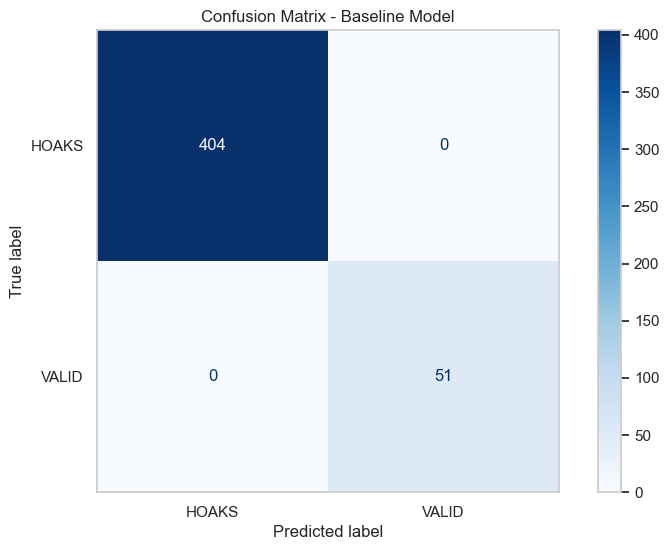

In [7]:
# Prediksi
y_pred_baseline = baseline_model.predict(X_test)

# Metrik
print("--- Laporan Klasifikasi Model Baseline (Logistic Regression) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_baseline) * 100:.2f}%")
print(classification_report(y_test, y_pred_baseline, target_names=['HOAKS', 'VALID']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HOAKS', 'VALID'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.grid(False)
plt.show()

### B. Evaluasi Model Deep Learning IndoBERT Lokal pada Test Set

Kita akan memuat bobot model IndoBERT lokal dari `models/indobert_hoax_model` dan mengevaluasi kinerjanya pada dataset uji.

> **Catatan:** Cell ini memerlukan pustaka `torch` dan `transformers`. Jika belum terinstal, jalankan: `pip install torch transformers`

In [8]:
# Import torch dan transformers di sini agar cell sebelumnya tetap bisa jalan
try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    TORCH_AVAILABLE = True
    print(f"PyTorch versi {torch.__version__} berhasil dimuat!")
except (ImportError, OSError):
    TORCH_AVAILABLE = False
    print("WARNING: Gagal memuat PyTorch/Transformers (mungkin karena masalah DLL Windows).")
    print("Cell evaluasi IndoBERT akan dilewati.")

Cell evaluasi IndoBERT akan dilewati.


In [9]:
MODEL_PATH = "../models/indobert_hoax_model"

if TORCH_AVAILABLE and os.path.exists(MODEL_PATH):
    print("Memuat model IndoBERT dari folder lokal...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    model.eval()
    
    bert_preds = []
    batch_size = 16
    test_texts = test_df['text'].tolist()
    
    # Evaluasi batch demi batch
    for i in tqdm(range(0, len(test_texts), batch_size), desc="Evaluasi IndoBERT"):
        batch_texts = test_texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            add_special_tokens=True,
            max_length=64,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        with torch.no_grad():
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1).tolist()
            bert_preds.extend(preds)
            
    print("\n--- Laporan Klasifikasi Model IndoBERT Lokal ---")
    print(f"Akurasi: {accuracy_score(y_test, bert_preds) * 100:.2f}%")
    print(classification_report(y_test, bert_preds, target_names=['HOAKS', 'VALID']))
    
    # Plot Confusion Matrix
    cm_bert = confusion_matrix(y_test, bert_preds)
    disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=['HOAKS', 'VALID'])
    disp_bert.plot(cmap='Greens')
    plt.title('Confusion Matrix - IndoBERT Model')
    plt.grid(False)
    plt.show()
elif not TORCH_AVAILABLE:
    print("Dilewati: torch/transformers belum terinstal.")
else:
    print(f"Model IndoBERT tidak ditemukan di path: {MODEL_PATH}. Pastikan model sudah diekstrak.")

Dilewati: torch/transformers belum terinstal.


### C. Pembuktian Kebocoran Dataset & Masalah Shortcut Learning (OOD Evaluation)

Meskipun hasil akurasi model pada dataset pengujian bernilai sempurna (100%), mari kita uji model-model ini dengan klaim pendek yang kita ketahui validitas medisnya secara ilmiah. Uji coba ini membuktikan apakah model benar-benar memahami kebenaran medis.

In [10]:
claims_test = [
    # Klaim medis VALID yang ditulis secara pendek
    "Paracetamol adalah obat penurun panas.",
    "Ibu hamil disarankan untuk mengonsumsi asam folat guna mencegah cacat lahir.",
    "Mencuci tangan dengan sabun dan air mengalir efektif membunuh kuman.",
    
    # Klaim HOAKS yang ditulis secara pendek
    "Minum air hangat dapat membunuh virus corona.",
    "Vaksin COVID-19 mengandung chip mikro 5G."
]

print("=== PENGUJIAN KLAIM OOD (OUT-OF-DISTRIBUTION) ===\n")

# 1. Evaluasi pada Model Baseline TF-IDF
print("[Model Baseline TF-IDF + Logistic Regression]")
for c in claims_test:
    clean_c = preprocess_text(c, remove_bias=True)
    feats = vectorizer.transform([clean_c])
    pred = baseline_model.predict(feats)[0]
    prob = baseline_model.predict_proba(feats)[0][pred]
    label_str = "VALID" if pred == 1 else "HOAKS"
    print(f"Klaim: '{c}'")
    print(f"  -> Prediksi: {label_str} ({prob*100:.2f}%)")
print("\n" + "="*50 + "\n")

# 2. Evaluasi pada Model IndoBERT
if TORCH_AVAILABLE and os.path.exists(MODEL_PATH):
    print("[Model IndoBERT Deep Learning]")
    for c in claims_test:
        inputs = tokenizer(c, add_special_tokens=True, max_length=64, padding="max_length", truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            prob = torch.softmax(outputs.logits, dim=1).flatten().tolist()
            pred = torch.argmax(outputs.logits, dim=1).item()
        label_str = "VALID" if pred == 1 else "HOAKS"
        print(f"Klaim: '{c}'")
        print(f"  -> Prediksi: {label_str} ({prob[pred]*100:.2f}%)")
else:
    print("Model IndoBERT tidak tersedia untuk pengetesan OOD.")

=== PENGUJIAN KLAIM OOD (OUT-OF-DISTRIBUTION) ===

[Model Baseline TF-IDF + Logistic Regression]
Klaim: 'Paracetamol adalah obat penurun panas.'
  -> Prediksi: HOAKS (54.11%)
Klaim: 'Ibu hamil disarankan untuk mengonsumsi asam folat guna mencegah cacat lahir.'
  -> Prediksi: HOAKS (79.60%)
Klaim: 'Mencuci tangan dengan sabun dan air mengalir efektif membunuh kuman.'
  -> Prediksi: HOAKS (85.14%)
Klaim: 'Minum air hangat dapat membunuh virus corona.'
  -> Prediksi: HOAKS (95.15%)
Klaim: 'Vaksin COVID-19 mengandung chip mikro 5G.'
  -> Prediksi: HOAKS (97.30%)


Model IndoBERT tidak tersedia untuk pengetesan OOD.


## 8. Kesimpulan & Rekomendasi

### Kesimpulan Hasil Analisis:
1. **Ilusi Performa Sempurna (100% Accuracy)**:
   Model baseline (TF-IDF) dan IndoBERT menghasilkan akurasi 100% pada dataset uji. Namun, performa sempurna ini adalah **ilusi** yang disebabkan oleh format dataset yang tidak seimbang secara struktural (*bias panjang teks*).
2. **Shortcut Learning / Data Leakage**:
   * Klaim **HOAKS** (kelas 0) selalu pendek (rata-rata 104 karakter) dan berformat judul klaim media sosial.
   * Klaim **VALID** (kelas 1) selalu panjang (rata-rata 583 karakter) dan berformat penjelasan penyakit medis Alodokter.
   * Akibatnya, model hanya mempelajari pintasan (*shortcut*) bahwa teks pendek = HOAKS, sedangkan teks panjang = VALID. 
3. **Kegagalan Generalisasi**:
   Saat diuji dengan kalimat medis valid berukuran pendek (seperti *"Paracetamol adalah obat penurun panas"*), model dengan tingkat keyakinan tinggi mengklasifikasikannya sebagai **HOAKS**.

### Rekomendasi Solusi:
1. **Penyelarasan Panjang Teks**: Mengekstraksi inti klaim singkat dari artikel VALID Alodokter untuk disandingkan dengan klaim pendek HOAKS.
2. **Pembersihan Kebocoran Kata**: Menghapus kata pemicu bias seperti kata *'salah'*, *'hoaks'*, dan domain website dari dataset latih.
3. **Augmentasi Data**: Menambah kuantitas dan variasi kalimat pendek valid pada kelas minoritas (VALID).